In [4]:
import numpy as np
from matplotlib import pyplot as plt
data = np.load('outputs/probability_classifier/prob_data.npz')

raw_data = data['raw_data']
classifier_out = data['classifier_out']
prob_out = data['prob_out']

data_path = '/media/dhruv/a7519aee-b272-44ae-a117-1f1ea1796db6/2024/arcmg/data/pendulum_lqr/pendulum_roa.txt'
data = np.loadtxt(data_path)[::10, 1:]

data[:, 0] /= np.pi
data[:, 1] /= (2*np.pi)

data.shape, classifier_out.shape, prob_out.shape

((79066, 3), (79066, 3), (79066, 3))

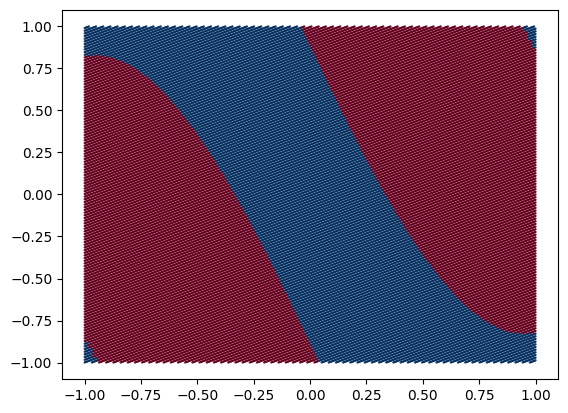

In [5]:
plt.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)

Accuracy: 0.3123972377507399
False positives: 25263
False negatives: 29103
True positives: 1466
True negatives: 23234


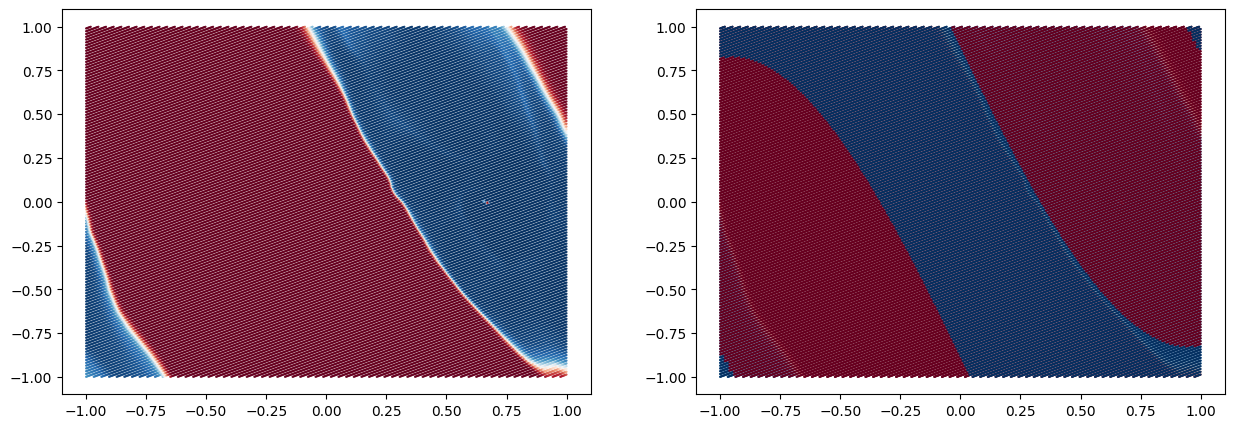

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(raw_data[:, 0], raw_data[:, 1], c=classifier_out[:, 1], cmap='RdBu', s=0.3)

# ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=classifier_out[:, 1], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)

# accuracy
accuracy = ((classifier_out[:, 1] > 0.5)== data[:, 2]).mean()
print(f'Accuracy: {accuracy}')

# generate false positives, false negatives, true positives, true negatives and plot the matrix
false_positives = np.logical_and(classifier_out[:, 1] > 0.5, data[:, 2] == 0)
false_negatives = np.logical_and(classifier_out[:, 1] < 0.5, data[:, 2] == 1)
true_positives = np.logical_and(classifier_out[:, 1] > 0.5, data[:, 2] == 1)
true_negatives = np.logical_and(classifier_out[:, 1] < 0.5, data[:, 2] == 0)


print(f'False positives: {false_positives.sum()}')
print(f'False negatives: {false_negatives.sum()}')
print(f'True positives: {true_positives.sum()}')
print(f'True negatives: {true_negatives.sum()}')


Accuracy: 0.9865681835428629
False positives: 243
False negatives: 819
True positives: 29750
True negatives: 48254


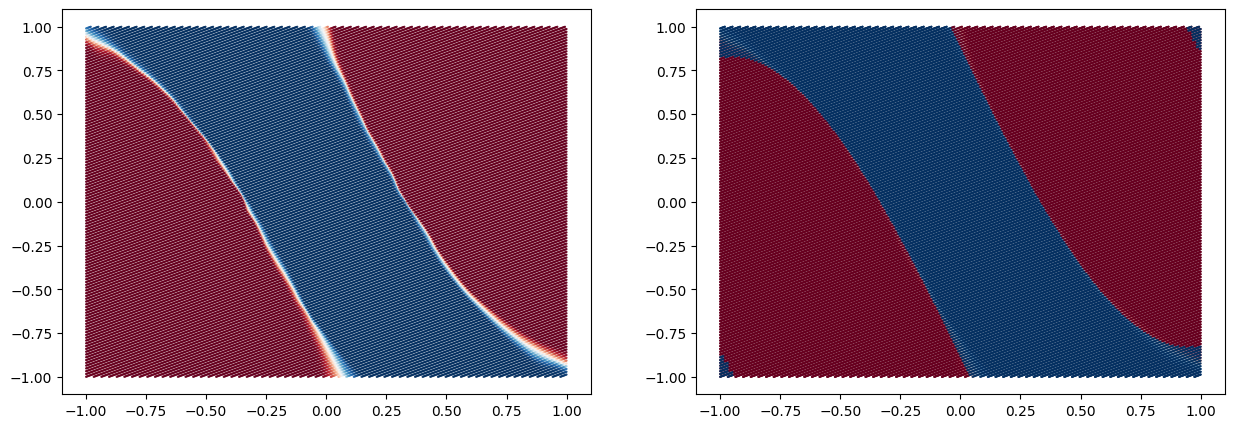

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(raw_data[:, 0], raw_data[:, 1], c=prob_out[:, 0], cmap='RdBu', s=0.3)

ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=prob_out[:, 0], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)

# accuracy
accuracy = ((prob_out[:, 0] > 0.5)== data[:, 2]).mean()
print(f'Accuracy: {accuracy}')

# generate false positives, false negatives, true positives, true negatives and plot the matrix
false_positives = np.logical_and(prob_out[:, 0] > 0.5, data[:, 2] == 0)
false_negatives = np.logical_and(prob_out[:, 0] < 0.5, data[:, 2] == 1)
true_positives = np.logical_and(prob_out[:, 0] > 0.5, data[:, 2] == 1)
true_negatives = np.logical_and(prob_out[:, 0] < 0.5, data[:, 2] == 0)


print(f'False positives: {false_positives.sum()}')
print(f'False negatives: {false_negatives.sum()}')
print(f'True positives: {true_positives.sum()}')
print(f'True negatives: {true_negatives.sum()}')

In [1]:
total_prob = classifier_out[:, 0] + classifier_out[:, 1] + classifier_out[:, 2]

norm_probs = {
    i: classifier_out[:, i] / total_prob for i in range(3)
}

norm_probs[1] += norm_probs[2]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].scatter(raw_data[:, 0], raw_data[:, 1], c=norm_probs[0], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=norm_probs[0], cmap='RdBu', s=0.3)
ax[1].scatter(raw_data[:, 0], raw_data[:, 1], c=data[:, 2], cmap='RdBu', s=0.3)


# accuracy
accuracy = ((norm_probs[0] > 0.5)== data[:, 2]).mean()
print(f'Accuracy: {accuracy}')

# generate false positives, false negatives, true positives, true negatives and plot the matrix
false_positives = np.logical_and(norm_probs[0] > 0.5, data[:, 2] == 0)
false_negatives = np.logical_and(norm_probs[0] < 0.5, data[:, 2] == 1)
true_positives = np.logical_and(norm_probs[0] > 0.5, data[:, 2] == 1)
true_negatives = np.logical_and(norm_probs[0] < 0.5, data[:, 2] == 0)


print(f'False positives: {false_positives.sum()}')
print(f'False negatives: {false_negatives.sum()}')
print(f'True positives: {true_positives.sum()}')
print(f'True negatives: {true_negatives.sum()}')

NameError: name 'classifier_out' is not defined